In [1]:
import matplotlib.pyplot as plt  
import numpy as np               
import pandas as pd              
from scipy import stats          
import geopandas as gpd
import seaborn as sns
import wquantiles
import statsmodels.api as sm

# Data understanding

###  Leitura do dataset

In [2]:
listing = "dataset/listings.csv"
caminho_excell = "Excell"
df = pd.read_csv(listing)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,48154,Precioso apartamento con wifi,219476,Antonio,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,83.0,3,197,2025-09-15,1.08,4,150,26,VT-41540-V
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775,Maria De La Piedad,POBLATS DEL SUD,EL SALER,39.36335,-0.31932,Entire home/apt,390.0,10,1,2013-07-02,0.01,5,20,0,VT32745V
2,149715,1900 Style Valencian Beach Home for 10px,5947,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,245.0,2,313,2025-09-15,1.81,1,287,41,ESFCTU000046025000580569000000000000000000VT-3...
3,165971,★ Architectural touch! ★,791187,Inés,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,124.0,5,576,2025-09-03,3.34,8,106,46,VT-32757-V
4,182221,Apartments Calatrava City Valencia,1315567,Chiara,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,137.0,3,9,2025-03-17,0.07,1,176,1,VT-38755-V


### Tipos de dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7844 entries, 0 to 7843
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7844 non-null   int64  
 1   name                            7844 non-null   object 
 2   host_id                         7844 non-null   int64  
 3   host_name                       7838 non-null   object 
 4   neighbourhood_group             7844 non-null   object 
 5   neighbourhood                   7844 non-null   object 
 6   latitude                        7844 non-null   float64
 7   longitude                       7844 non-null   float64
 8   room_type                       7844 non-null   object 
 9   price                           6979 non-null   float64
 10  minimum_nights                  7844 non-null   int64  
 11  number_of_reviews               7844 non-null   int64  
 12  last_review                     68

### descrição inicial

In [4]:
quantiva_discretas = ["number_of_reviews_ltm", "number_of_reviews", "minimum_nights", "calculated_host_listings_count"]
quantiva_continuas = ["latitude", "longitude", "price", "reviews_per_month", "availability_365"]
qualitativas_nominais = ["neighbourhood_group", "neighbourhood", "host_name","room_type","name"]
useless = ["id","host_id", "license"]
df["availability_365"].head(10)

0    150
1     20
2    287
3    106
4    176
5    161
6    160
7     88
8      1
9     45
Name: availability_365, dtype: int64

### Colocar as variáveis nominais como do tipo categóricas

In [5]:
for col in qualitativas_nominais + useless:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7844 entries, 0 to 7843
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              7844 non-null   category
 1   name                            7844 non-null   category
 2   host_id                         7844 non-null   category
 3   host_name                       7838 non-null   category
 4   neighbourhood_group             7844 non-null   category
 5   neighbourhood                   7844 non-null   category
 6   latitude                        7844 non-null   float64 
 7   longitude                       7844 non-null   float64 
 8   room_type                       7844 non-null   category
 9   price                           6979 non-null   float64 
 10  minimum_nights                  7844 non-null   int64   
 11  number_of_reviews               7844 non-null   int64   
 12  last_review         

## range de cada variável

### Usadas no trabalho

In [6]:
amplitude_data = []

for col in quantiva_discretas + quantiva_continuas:
    amplitude_data.append({
        "Variável": col,
        "Amplitude": f"{df[col].min()},{df[col].max()}"
    })

for col in qualitativas_nominais + useless:
    categorias = df[col].cat.categories.tolist()
    amplitude_data.append({
        "Variável": col,
        "Amplitude": None,
        "Categorias": ", ".join(map(str, categorias))
    })

amplitude_df = pd.DataFrame(amplitude_data)
amplitude_df.to_excel(f"{caminho_excell}/valores.xlsx", index=False)
display(amplitude_df)

,Variável,Amplitude,Categorias
0,number_of_reviews_ltm,"0,367",NaN
1,number_of_reviews,"0,935",NaN
2,minimum_nights,"1,366",NaN
3,calculated_host_listings_count,"1,103",NaN
4,latitude,"39.2799863,39.54579",NaN
5,longitude,"-0.42584,-0.27628",NaN
6,price,"8.0,40000.0",NaN
7,reviews_per_month,"0.01,37.71",NaN
8,availability_365,"0,365",NaN
9,neighbourhood_group,None,"ALGIROS, BENICALAP, BENIMACLET, CAMINS AL GRAU..."


In [7]:
def describe_quantative(tipo, excell ):
    desc = df[tipo].describe().round(3)

    desc.loc["amplitude"] = (df[tipo].max() - df[tipo].min()).round(3)
    desc.loc["IQR"] = (df[tipo].quantile(0.75) - df[tipo].quantile(0.25)).round(3)
    desc.loc["assimetria"] = df[tipo].skew().round(3)
    desc.loc["curtose"] = df[tipo].kurtosis().round(3)
    if excell == 1:
        desc.to_excel(f"desc_{tipo}.xlsx")
    display(desc)
    return
describe_quantative(quantiva_continuas, 0)

,latitude,longitude,price,reviews_per_month,availability_365
count,7844.000,7844.000,6979.000,6867.000,7844.000
mean,39.467,-0.364,164.113,1.695,185.951
std,0.019,0.023,732.639,1.666,120.086
min,39.280,-0.426,8.000,0.010,0.000
25%,39.461,-0.380,71.000,0.470,77.000
50%,39.469,-0.371,102.000,1.170,179.000
75%,39.475,-0.344,140.000,2.490,305.000
max,39.546,-0.276,40000.000,37.710,365.000
amplitude,0.266,0.150,39992.000,37.700,365.000
IQR,0.013,0.036,69.000,2.020,228.000


In [8]:
df = df.drop("id", axis=1)

In [9]:
# função para descrever variáveis categóricas
def describe_categorical(df, variaveis, excell=0):
    resultado = []

    for var in variaveis:
        serie = df[var]
        
        n = serie.count()
        cardinalidade = serie.nunique(dropna=True)
        
        if not serie.mode().empty:
            moda = serie.mode().iloc[0]
            freq_moda = serie.value_counts().iloc[0]
            freq_rel_moda = round((freq_moda / n) * 100, 3) if n > 0 else 0
        else:
            moda = None
            freq_moda = None
            freq_rel_moda = None

        resultado.append({
            "Variável": var,
            "N": n,
            "Cardinalidade": cardinalidade,
            "Moda": moda,
            "Frequência da moda": freq_moda,
            "Frequência relativa da moda (%)": freq_rel_moda
        })
    resultado_df = pd.DataFrame(resultado)
    if excell:
        resultado_df.to_excel("desc_categoricas.xlsx", index=False)
    return pd.DataFrame(resultado)
describe_categorical(df,qualitativas_nominais )

,Variável,N,Cardinalidade,Moda,Frequência da moda,Frequência relativa da moda (%)
0,neighbourhood_group,7844,19,POBLATS MARITIMS,1471,18.753
1,neighbourhood,7844,85,CABANYAL-CANYAMELAR,750,9.561
2,host_name,7838,1764,Marta,124,1.582
3,room_type,7844,4,Entire home/apt,5782,73.712
4,name,7844,7515,Habitación en Valencia,21,0.268


A robust estimate of variability is the median absolute deviation from the median or MAD
Podemos usar isto no preço

In [10]:
print(sm.robust.scale.mad(df['price']))


nan


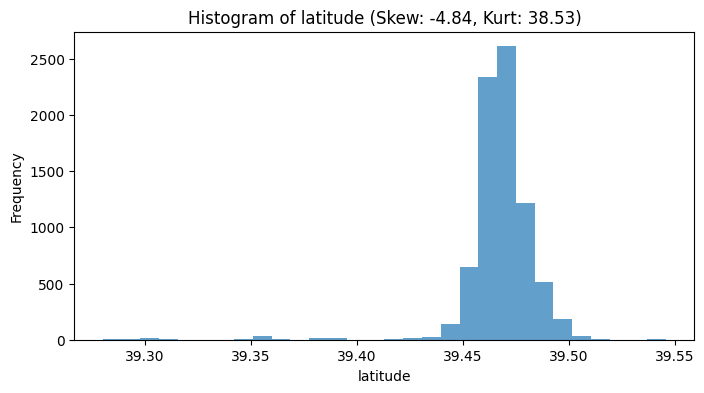

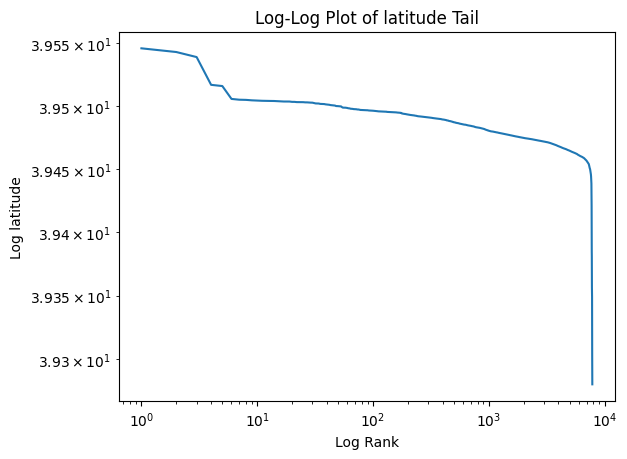

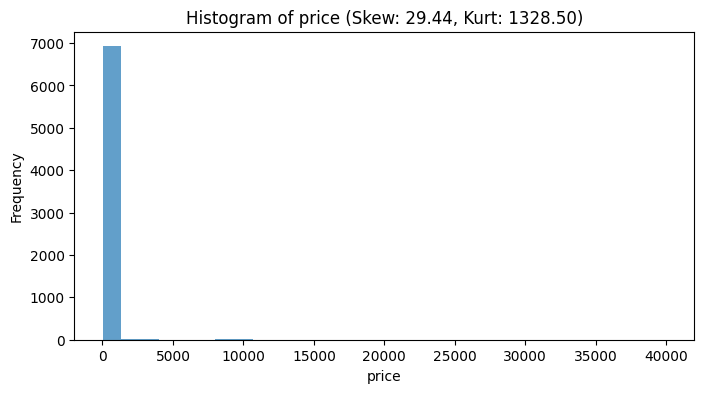

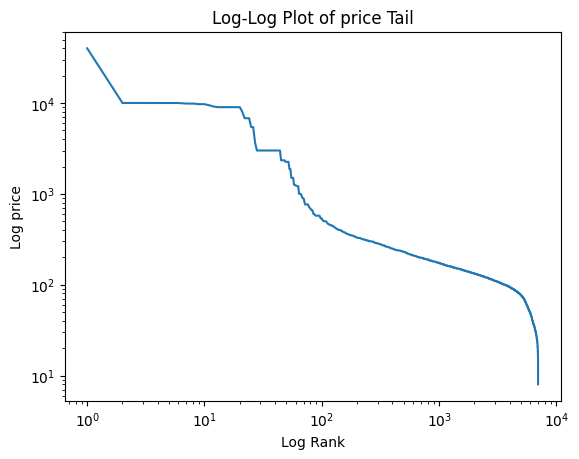

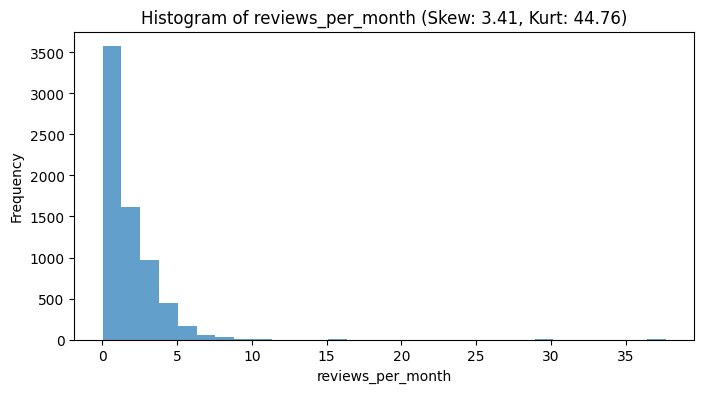

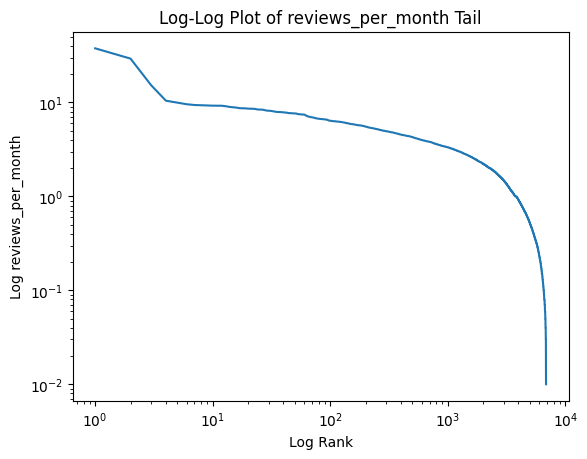

In [11]:
# Loop through continuous quantitative variables to check for heavy tails based on skewness and kurtosis
for col in quantiva_continuas:
    ser = df[col].dropna()
    if ser.empty:
        continue
    
    # Compute skewness and kurtosis
    skew = ser.skew()
    kurt = ser.kurtosis()
    
    # Plot only if kurtosis > 3 (leptokurtic, potential heavy tails) or skewness > 1 (right-skewed)
    if kurt > 3 or abs(skew) > 1:
        # Histogram
        ser.plot.hist(bins=30, alpha=0.7, figsize=(8, 4), title=f'Histogram of {col} (Skew: {skew:.2f}, Kurt: {kurt:.2f})')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
        
        # Log-log plot of tail
        sorted_ser = ser.sort_values(ascending=False)
        ranks = np.arange(1, len(sorted_ser) + 1)
        plt.loglog(ranks, sorted_ser)
        plt.xlabel('Log Rank')
        plt.ylabel(f'Log {col}')
        plt.title(f'Log-Log Plot of {col} Tail')
        plt.show()


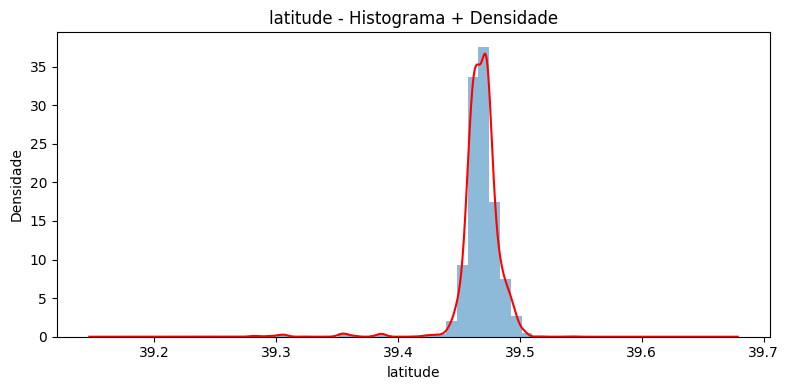

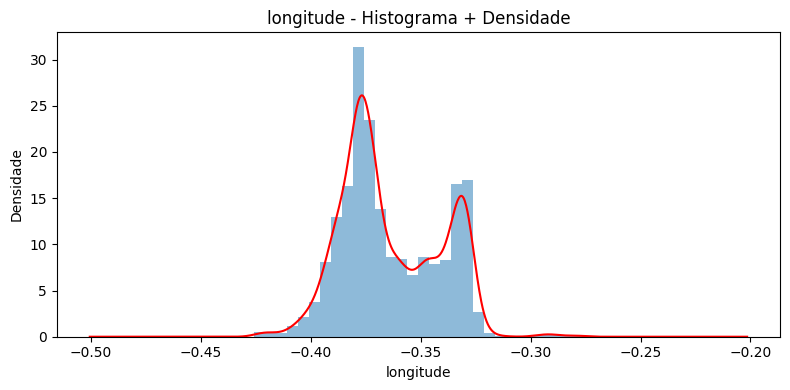

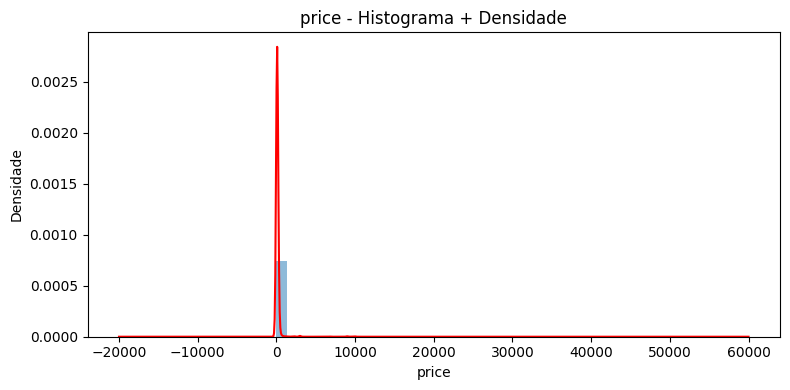

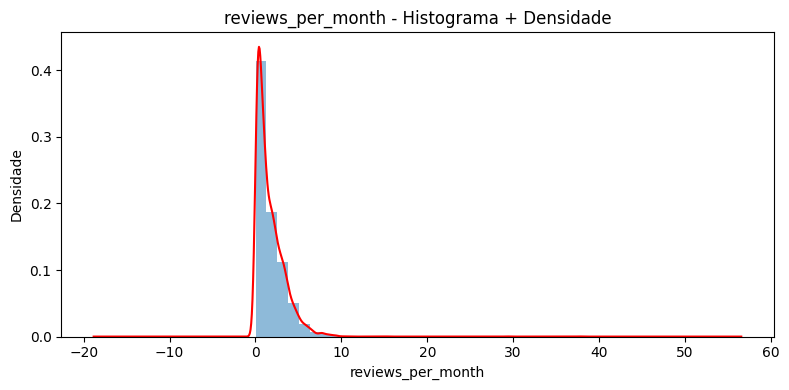

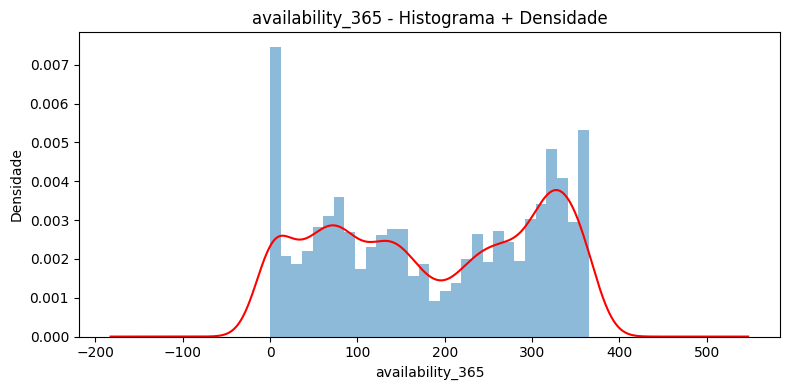

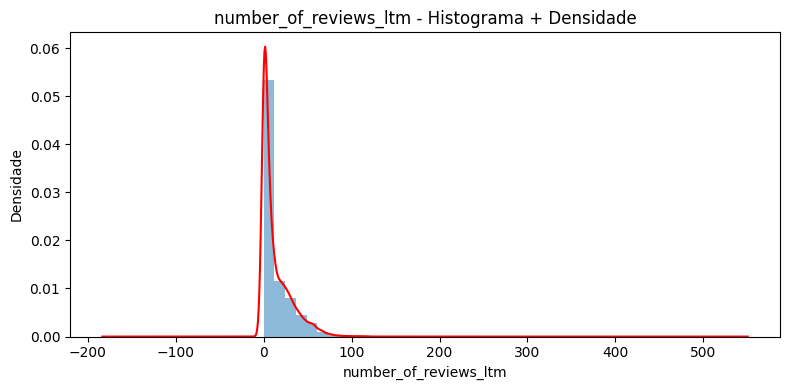

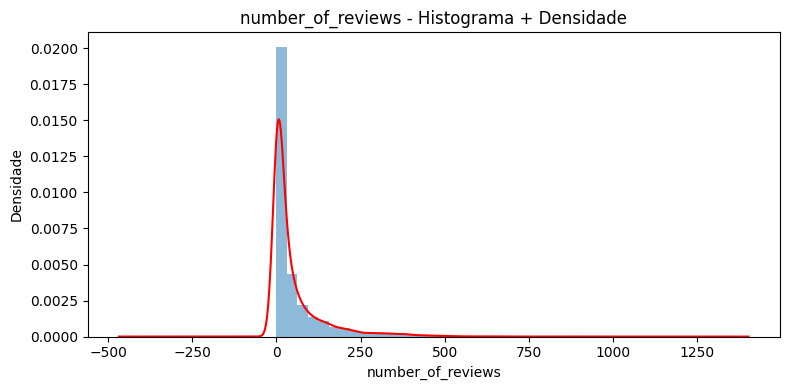

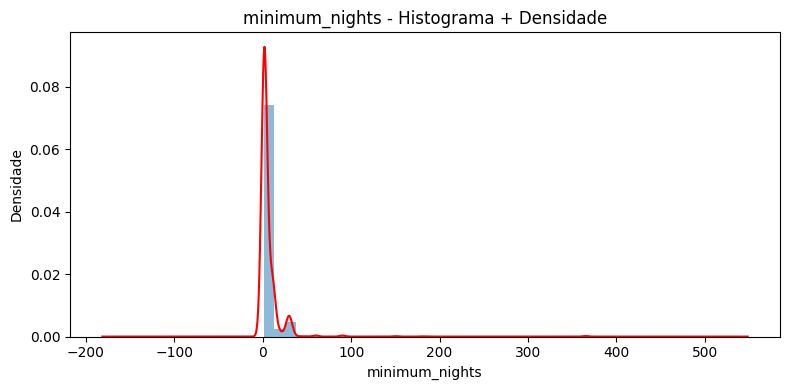

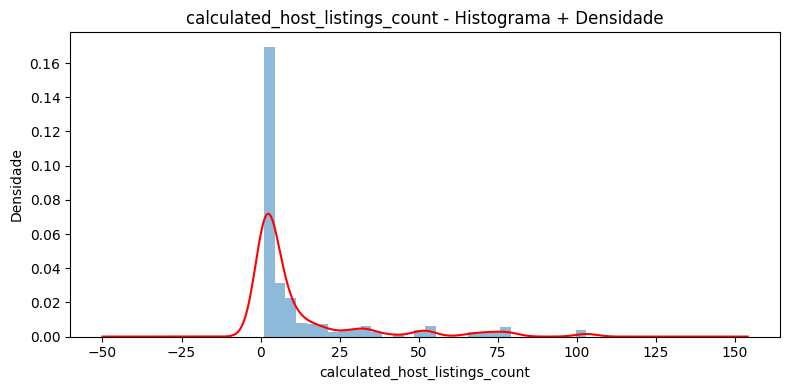

In [12]:
# hist + density para todas as variáveis quantitativas
quantiativas = quantiva_continuas + quantiva_discretas

for col in quantiativas:
    ser = df[col].dropna()
    if ser.empty:
        continue

    ax = ser.plot.hist(density=True, bins=30, alpha=0.5, figsize=(8, 4), title=f'{col} - Histograma + Densidade')
    ser.plot.density(ax=ax, color='red')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidade')
    plt.tight_layout()
    plt.show()

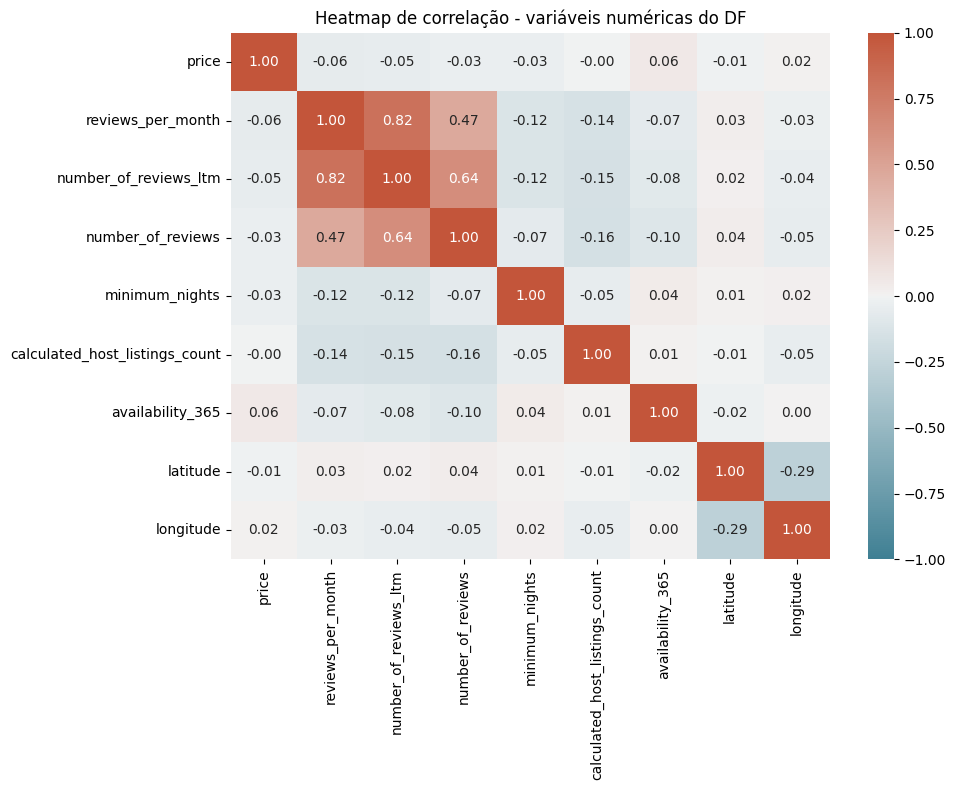

In [13]:
# Escolhendo colunas numéricas do df que fazem sentido para ver relações:
# price (target financeiro), availability_365 (ocupação/disponibilidade),
# reviews_per_month e number_of_reviews/_ltm (desempenho/aceitação),
# minimum_nights e calculated_host_listings_count (perfil de oferta),
# latitude/longitude (localização geográfica).
cols = [
    "price", "reviews_per_month", "number_of_reviews_ltm", "number_of_reviews",
    "minimum_nights", "calculated_host_listings_count",
    "availability_365", "latitude", "longitude"
]

corr = df[cols].dropna().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1,
            cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.title("Heatmap de correlação - variáveis numéricas do DF")
plt.tight_layout()
plt.show()

,price,reviews_per_month,number_of_reviews_ltm,number_of_reviews,minimum_nights,calculated_host_listings_count,availability_365,latitude,longitude
price,1.000000,-0.064229,-0.027741,0.019886,-0.135336,0.076399,0.031855,-0.010758,0.038158
reviews_per_month,-0.064229,1.000000,0.677220,0.473918,-0.083031,-0.077326,-0.020943,-0.008434,-0.001882
number_of_reviews_ltm,-0.027741,0.677220,1.000000,0.668281,-0.068720,-0.058937,-0.067962,-0.017386,0.002262
number_of_reviews,0.019886,0.473918,0.668281,1.000000,-0.010883,-0.094016,-0.100629,0.007474,0.004068
minimum_nights,-0.135336,-0.083031,-0.068720,-0.010883,1.000000,-0.124367,-0.107789,-0.000461,0.058030
calculated_host_listings_count,0.076399,-0.077326,-0.058937,-0.094016,-0.124367,1.000000,0.023674,-0.034343,-0.006957
availability_365,0.031855,-0.020943,-0.067962,-0.100629,-0.107789,0.023674,1.000000,-0.005337,-0.011003
latitude,-0.010758,-0.008434,-0.017386,0.007474,-0.000461,-0.034343,-0.005337,1.000000,-0.114425
longitude,0.038158,-0.001882,0.002262,0.004068,0.058030,-0.006957,-0.011003,-0.114425,1.000000


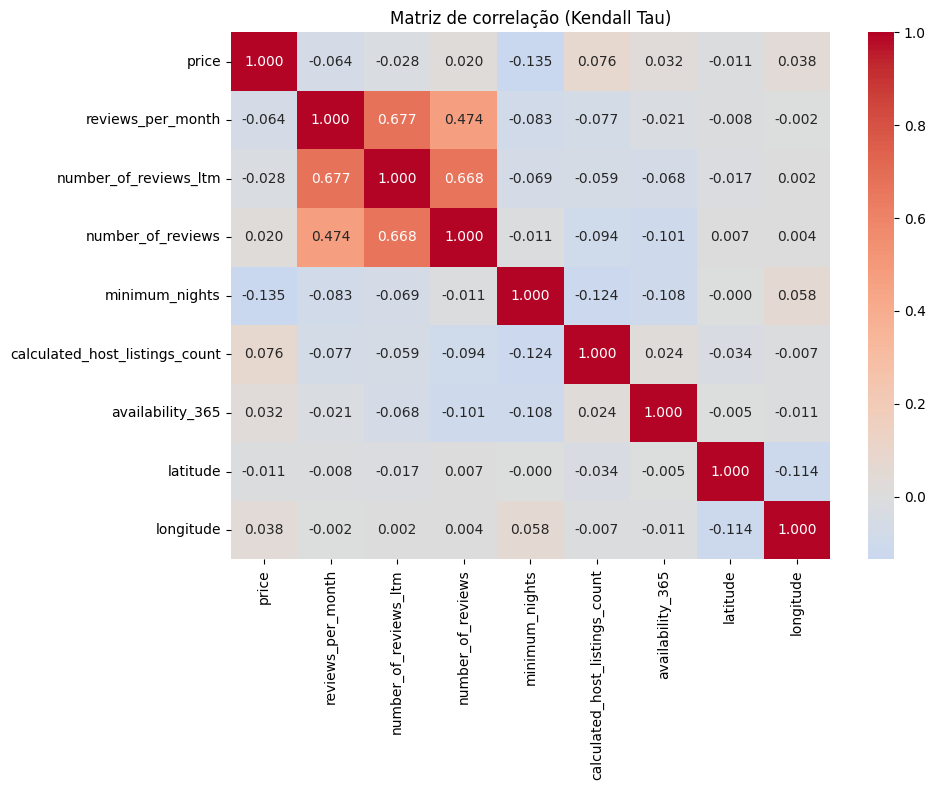

In [14]:
# correlação usando Kendall Tau para variáveis numéricas já definidas (cols)
kendall_corr = df[cols].corr(method='kendall')
display(kendall_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, fmt=".3f", cmap='coolwarm', center=0)
plt.title("Matriz de correlação (Kendall Tau)")
plt.tight_layout()
plt.show()

### Correlações

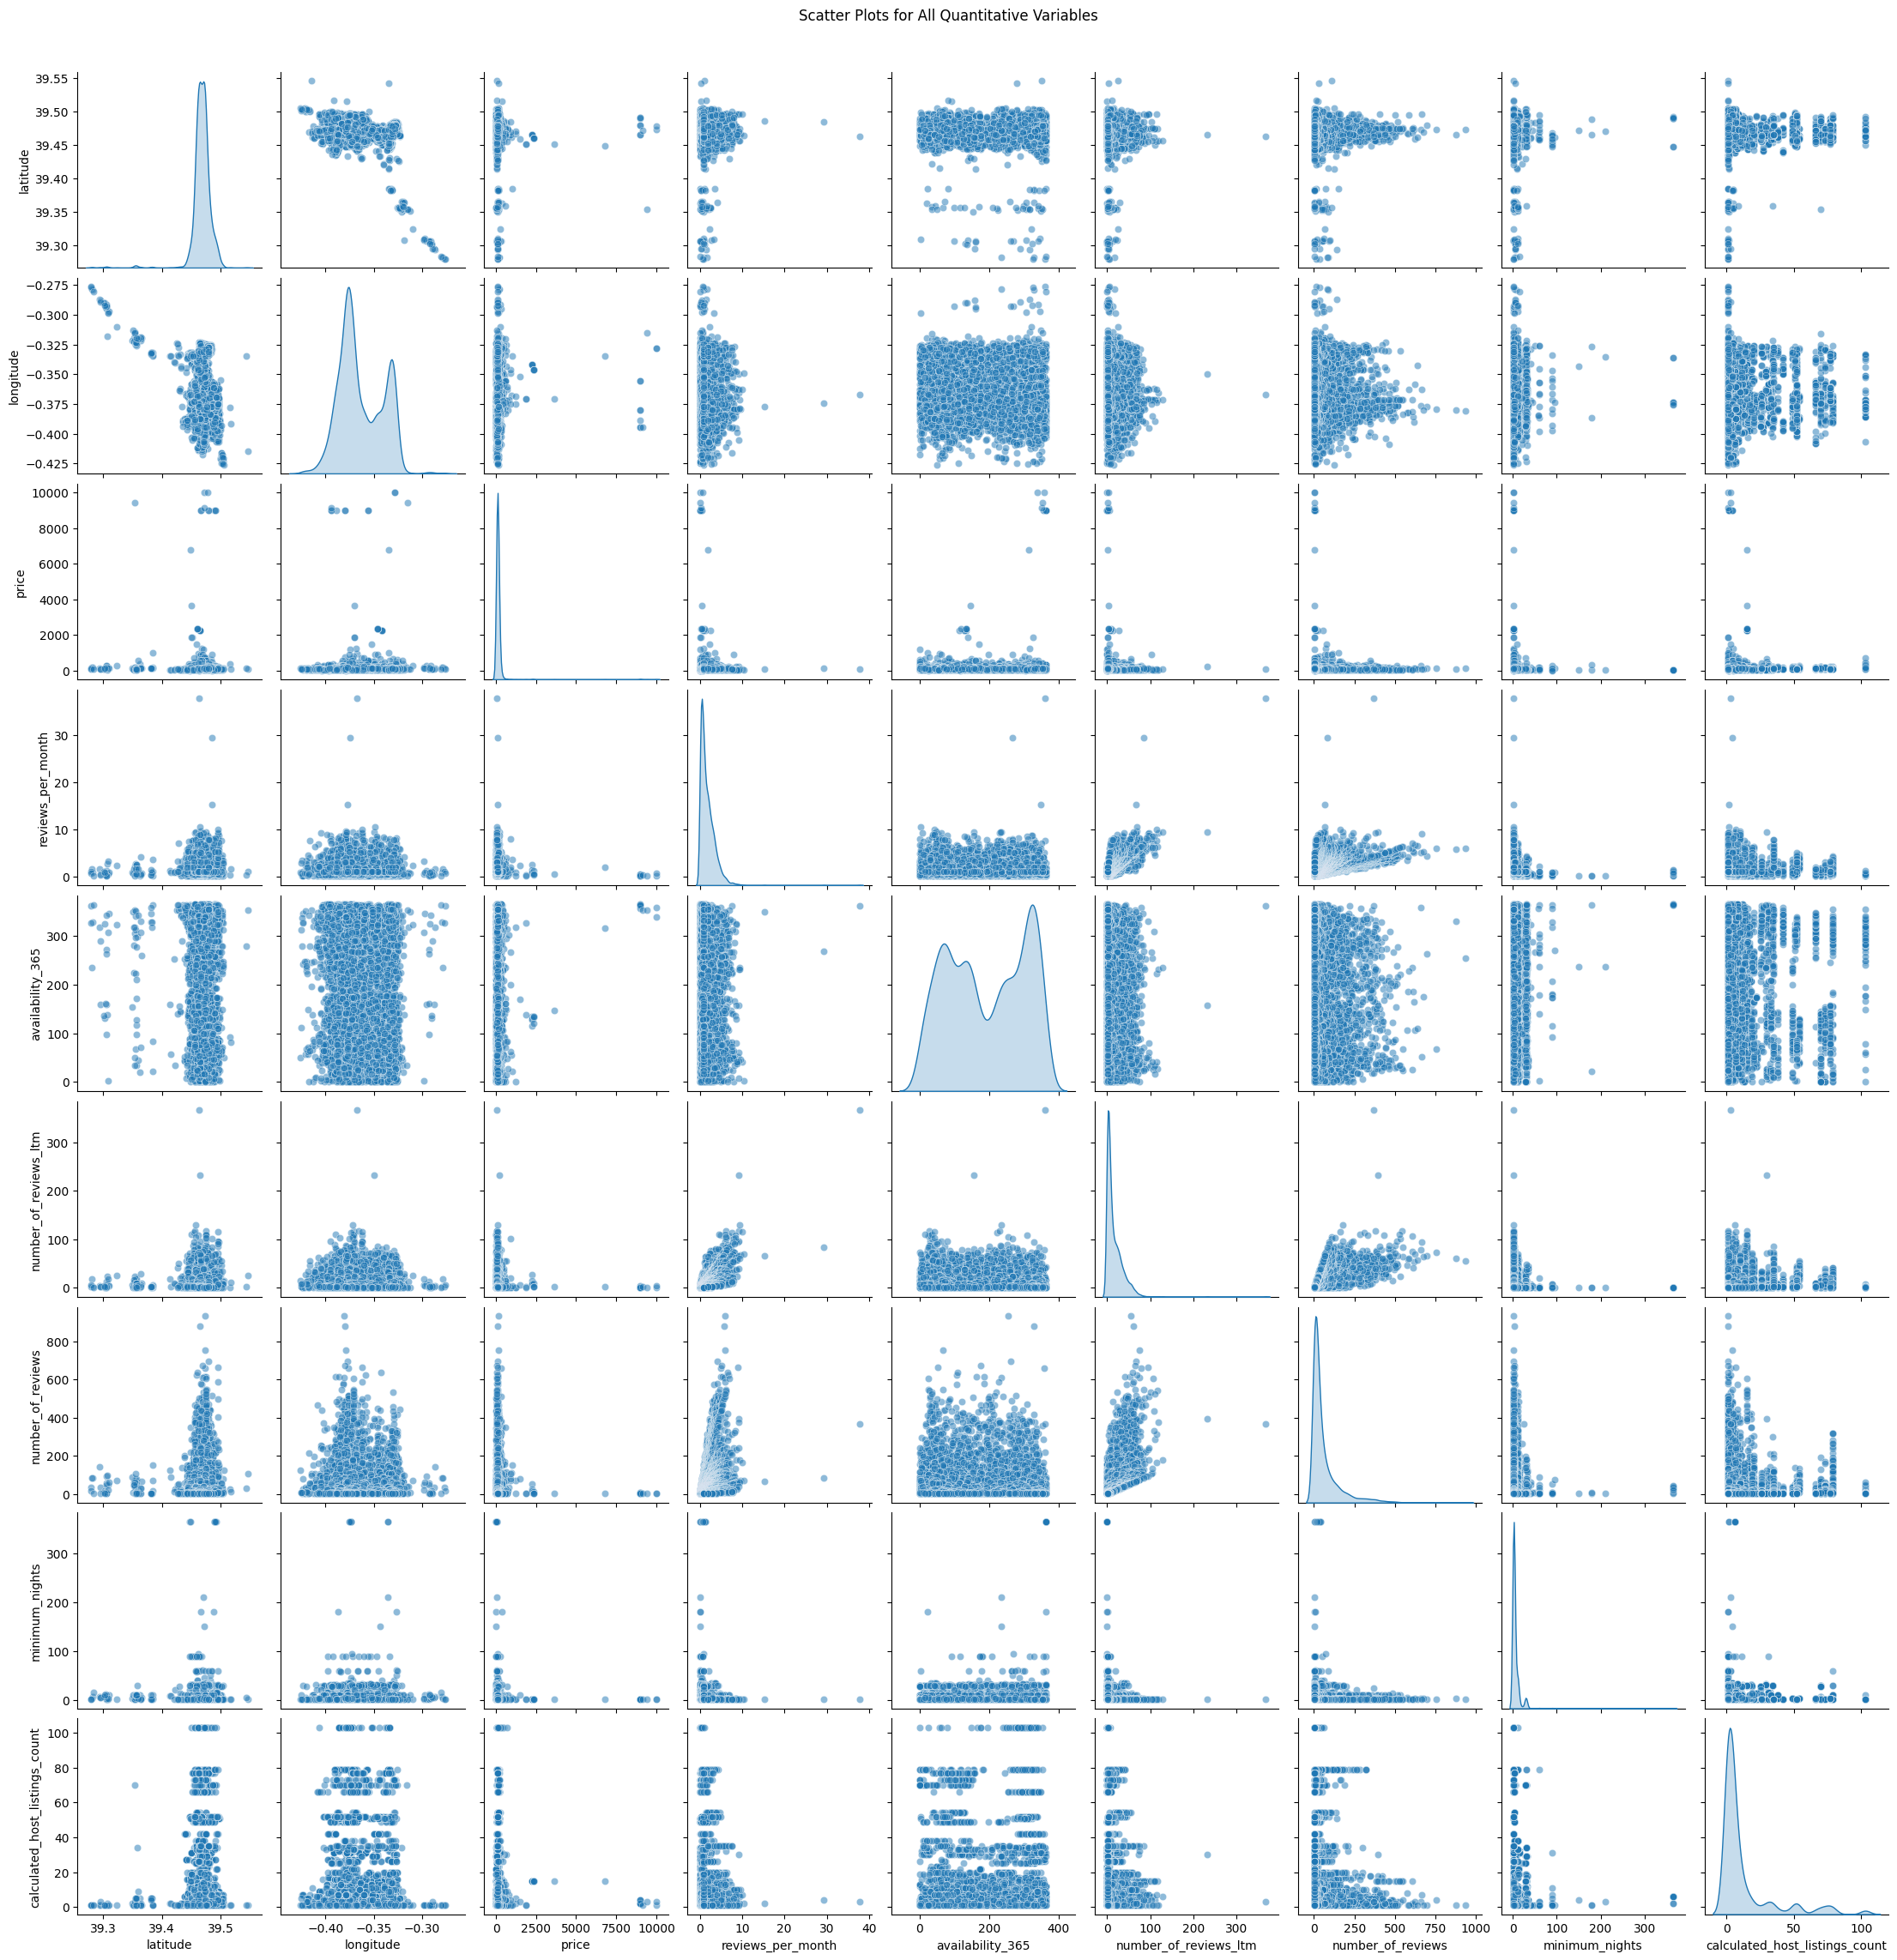

In [15]:
import seaborn as sns

import matplotlib.pyplot as plt

# Select quantitative variables
quantiativas = quantiva_continuas + quantiva_discretas

# Create pairplot for all quantitative variables
sns.pairplot(df[quantiativas].dropna(), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Scatter Plots for All Quantitative Variables', y=1.02)
plt.show()

Text(0, 0.5, 'Latitude')

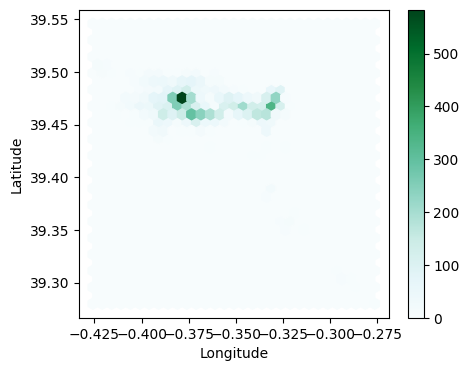

In [16]:
ax = df.plot.hexbin(x='longitude', y='latitude', gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

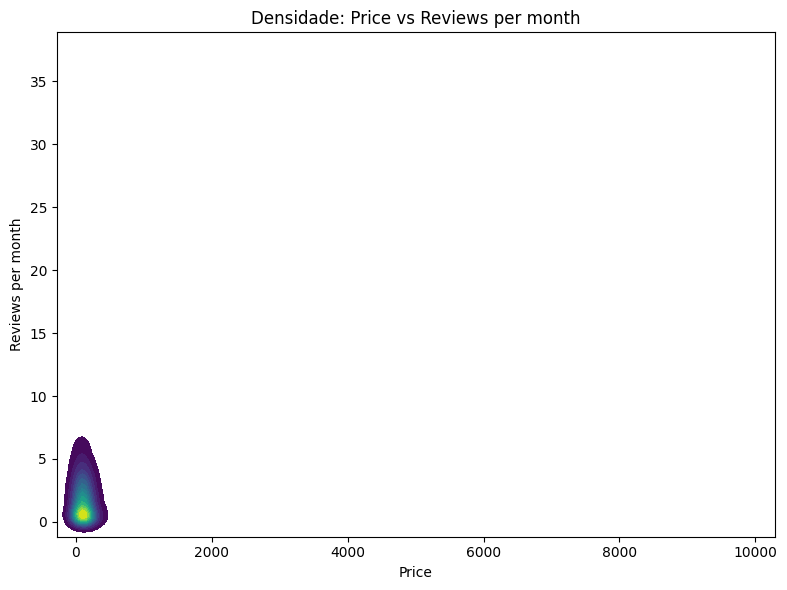

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(
    x=df['price'].dropna(),
    y=df['reviews_per_month'].dropna(),
    fill=True,
    thresh=0.05,
    levels=15,
    cmap='viridis',
    ax=ax
)

ax.set_xlabel('Price')
ax.set_ylabel('Reviews per month')
ax.set_title('Densidade: Price vs Reviews per month')

plt.tight_layout()
plt.show()

Variáveis categóricas

A useful way to summarize two categorical variables is a contingency table—a table of counts by category. Table 1-8 shows the contingency table between the grade of a personal loan and the outcome of that loan. This is taken from data provided by Lending Club, a leader in the peer-to-peer lending business. The grade goes from A (high) to G (low). The outcome is either fully paid, current, late, or charged off (the balance of the loan is not expected to be collected). This table shows the count and row percentages. High-grade loans have a very low late/charge-off percentage as compared with lower-grade loans.

In [18]:
crosstab = pd.crosstab(df['neighbourhood_group'], df['room_type'], margins=True)
df_crosstab = crosstab.drop('All').copy()  # Exclude the 'All' row for processing
df_crosstab.loc[:, 'Entire home/apt':'Shared room'] = df_crosstab.loc[:, 'Entire home/apt':'Shared room'].div(df_crosstab['All'], axis=0)
df_crosstab['All'] = df_crosstab['All'] / sum(df_crosstab['All'])
perc_crosstab = df_crosstab
display(perc_crosstab)

C:\Users\ferol\AppData\Local\Temp\ipykernel_41960\3208072917.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.53958944 0.65068493 0.54320988 0.74074074 0.68656716 0.8364486
 0.6474359  0.76138148 0.56737589 0.75072886 0.55793991 0.72948328
 0.70621469 0.54901961 0.625      0.8968254  0.79537729 0.73587224
 0.51572327]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_crosstab.loc[:, 'Entire home/apt':'Shared room'] = df_crosstab.loc[:, 'Entire home/apt':'Shared room'].div(df_crosstab['All'], axis=0)
C:\Users\ferol\AppData\Local\Temp\ipykernel_41960\3208072917.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01173021 0.         0.         0.         0.         0.00155763
 0.         0.00156986 0.         0.01020408 0.         0.
 0.         0.         0.         0.         0.         0.00245

room_type,Entire home/apt,Hotel room,Private room,Shared room,All
neighbourhood_group,,,,,
ALGIROS,0.539589,0.011730,0.448680,0.000000,0.043473
BENICALAP,0.650685,0.000000,0.349315,0.000000,0.018613
BENIMACLET,0.543210,0.000000,0.456790,0.000000,0.010326
CAMINS AL GRAU,0.740741,0.000000,0.259259,0.000000,0.092937
CAMPANAR,0.686567,0.000000,0.313433,0.000000,0.017083
CIUTAT VELLA,0.836449,0.001558,0.161215,0.000779,0.163692
EL PLA DEL REAL,0.647436,0.000000,0.352564,0.000000,0.019888
EXTRAMURS,0.761381,0.001570,0.235479,0.001570,0.081209
JESUS,0.567376,0.000000,0.432624,0.000000,0.035951


## Verificar qualidade dos dados

### Colunas com Missing values

In [31]:
na_summary = df.isnull().sum()
na_columns = na_summary[na_summary > 0]
missing_table = pd.DataFrame({
    '# Valores Omissos': na_columns,
    'Valores omissos %': (na_columns / len(df) * 100).round(2)
})
print("Columns with missing values:")
display(missing_table)

Columns with missing values:


,# Valores Omissos,Valores omissos %
host_name,6,0.08
price,865,11.03
last_review,977,12.46
reviews_per_month,977,12.46
license,3311,42.21


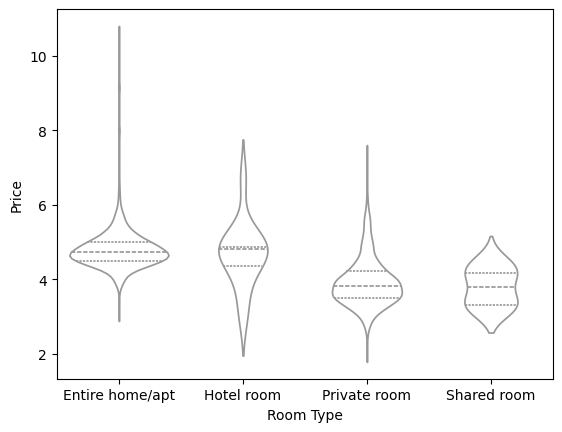

In [20]:
ax = sns.violinplot(x=df['room_type'], y=np.log(df['price']), inner='quartile', color='white')
ax.set_xlabel('Room Type')
ax.set_ylabel('Price')
plt.show()

# Data preparation

### Limpeza de dados

#### missings

### Feature engineering

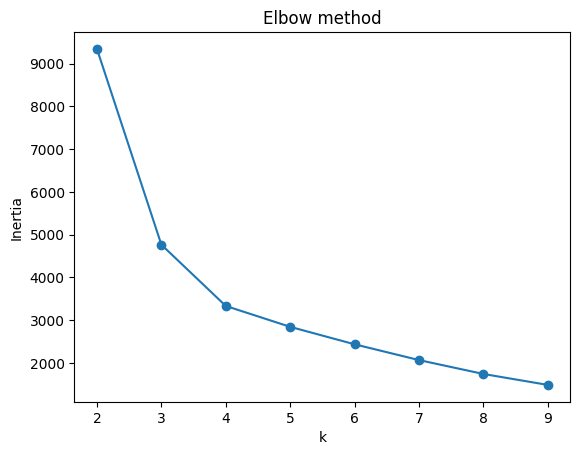

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score  # <<-- fix

# features geográficas
X_geo = df[['latitude', 'longitude']].astype(float)

# escalonamento
scaler = StandardScaler()
X_geo_scaled = scaler.fit_transform(X_geo)

# Elbow
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_geo_scaled)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_geo_scaled)
    score = silhouette_score(X_geo_scaled, labels)
    print(k, score)

# Clustering final
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['location_cluster'] = kmeans.fit_predict(X_geo_scaled)

# dummies se quiser usar em modelo
df = pd.get_dummies(df, columns=['location_cluster'], drop_first=True)
# Clustering final
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['location_cluster'] = kmeans.fit_predict(X_geo_scaled)

# dummies se quiser usar em modelo
df = pd.get_dummies(df, columns=['location_cluster'], drop_first=True)

In [22]:
df

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,location_cluster_1,location_cluster_2,location_cluster_3,location_cluster_4
0,Precioso apartamento con wifi,219476,Antonio,LA SAIDIA,MORVEDRE,39.483750,-0.375020,Entire home/apt,83.0,3,...,2025-09-15,1.08,4,150,26,VT-41540-V,False,False,True,False
1,PENTHOUSE ON FRONT LINE BEACH,670775,Maria De La Piedad,POBLATS DEL SUD,EL SALER,39.363350,-0.319320,Entire home/apt,390.0,10,...,2013-07-02,0.01,5,20,0,VT32745V,False,True,False,False
2,1900 Style Valencian Beach Home for 10px,5947,Susana Barbara,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.467460,-0.328130,Entire home/apt,245.0,2,...,2025-09-15,1.81,1,287,41,ESFCTU000046025000580569000000000000000000VT-3...,True,False,False,False
3,★ Architectural touch! ★,791187,Inés,EXTRAMURS,LA ROQUETA,39.467900,-0.382060,Entire home/apt,124.0,5,...,2025-09-03,3.34,8,106,46,VT-32757-V,False,False,False,False
4,Apartments Calatrava City Valencia,1315567,Chiara,CAMINS AL GRAU,AIORA,39.463430,-0.343250,Entire home/apt,137.0,3,...,2025-03-17,0.07,1,176,1,VT-38755-V,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7839,Apartamento familiar,719445669,Meline,CIUTAT VELLA,SANT FRANCESC,39.470011,-0.376613,Entire home/apt,168.0,1,...,NaN,NaN,1,338,0,VT-082345-V,False,False,False,False
7840,"2 Habitación privada cerca del centro, wifi, m...",719672175,Miguelangel Jose,PATRAIX,FAVARA,39.455090,-0.392100,Private room,22.0,1,...,NaN,NaN,2,3,0,BAP153962V,False,False,False,True
7841,1 Habitación Céntrica Metro Segura con Llave,719672175,Miguelangel Jose,JESUS,L'HORT DE SENABRE,39.454330,-0.391180,Private room,20.0,1,...,NaN,NaN,2,7,0,BAP153962A,False,False,False,True
7842,Habitación 2,682595718,Cecilia Inés,EXTRAMURS,ARRANCAPINS,39.459802,-0.382912,Private room,41.0,1,...,NaN,NaN,3,343,0,VT 14304256 V,False,False,False,True


Transformar 

Exemplo: Murder rate ajudastado à população

In [23]:
np.average(state['Murder.Rate'], weights=state['Population']) 
wquantiles.median(state['Murder.Rate'], weights=state['Population'])

NameError: name 'state' is not defined

### Selecionar Variáveis

# Modelação dos dados

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# usar neighbourhood como preditor para price (modelo linear simples com dummies)
df_reg = df[['neighbourhood', 'price']].dropna()

X = pd.get_dummies(df_reg['neighbourhood'], drop_first=True)
y = df_reg['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred).round(4))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)).round(4))

coef = pd.Series(model.coef_, index=X.columns)
coef = coef.sort_values(ascending=False)
print("Intercept:", model.intercept_.round(4))
print("Melhores bairros (coef > 0):")
print(coef[coef > 0].head(10))
print("Piores bairros (coef < 0):")
print(coef[coef < 0].head(10))

AttributeError: 'float' object has no attribute 'round'